# Project: Wildfire Prediction

### Set up imports

In [1]:
!pip install pandas
!pip install scikit-learn
!pip install matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


### Load the data

In [2]:
# Import data from file, only using the first 5000 rows
wildfires_df = pd.read_csv('Dataset-A_US_Wildfire.csv', nrows = 5000)

### Inspect the data

In [3]:
# Look at the size (rows, columns)
wildfires_df.shape

(5000, 19)

In [4]:
# Look at the columns
print("Columns:", wildfires_df.columns)

Columns: Index(['latitude', 'longitude', 'datetime', 'Wildfire', 'pr', 'rmax', 'rmin',
       'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc',
       'etr', 'pet', 'vpd'],
      dtype='str')


In [5]:
# Look at the first 5 rows
wildfires_df.head()

,latitude,longitude,datetime,Wildfire,pr,rmax,rmin,sph,srad,tmmn,tmmx,vs,bi,fm100,fm1000,erc,etr,pet,vpd
0,48.128431,-97.276685,2018-08-15,No,0.0,78.6,14.9,0.00582,272.6,282.0,301.6,3.0,40.0,10.2,12.2,54.0,7.5,5.5,1.59
1,48.128431,-97.276685,2018-08-16,No,0.0,80.4,13.9,0.00676,264.0,283.9,304.9,3.0,40.0,9.7,12.0,56.0,8.2,5.9,1.93
2,48.128431,-97.276685,2018-08-17,No,0.0,70.9,20.4,0.00672,265.6,285.8,300.7,3.1,40.0,9.2,11.9,56.0,7.2,5.3,1.51
3,48.128431,-97.276685,2018-08-18,No,5.0,65.2,19.4,0.00756,261.4,289.0,303.3,5.1,0.0,9.9,12.0,40.0,10.0,6.9,1.85
4,48.128431,-97.276685,2018-08-19,No,0.0,100.0,42.2,0.00895,166.8,283.8,296.5,4.7,41.0,11.8,12.1,47.0,4.6,3.4,0.66


## Columns:
- pr = Precipitation
- rmax = Max daily relative humidity
- rmin = Min daily relative humidity
- sph = Specific humidity
- srad = Solar radiation
- tmmn = Min daily temperature
- tmmx = Max daily temperature
- vs = Wind speed
- bi = Burning index
- fm100 = 100-hr dead fuel moisture
- fm1000 = 1000-hr dead fuel moisture
- erc = Energy Release Component
- etr = Actual evapotranspiration
- pet = Potential evapotranspiration
- vpd = Vapor pressure deficit

In [6]:
# Look at the number of occurrences of wildfires
wildfires_df['Wildfire'].value_counts()

Wildfire
No     4775
Yes     225
Name: count, dtype: int64

In [7]:
# Data preprocessing: drop any missing values
wildfires_df = wildfires_df.dropna()

### Split the data for training and testing

In [8]:
# Assign values to X and Y
X = wildfires_df[['latitude', 'longitude', 'pr', 'rmax', 'rmin',
       'sph', 'srad', 'tmmn', 'tmmx', 'vs', 'bi', 'fm100', 'fm1000', 'erc',
       'etr', 'pet', 'vpd']]      
y = wildfires_df['Wildfire']

# Train Test Split (ADDED STRATIFY)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Define the hyperparameter grid

In [9]:
rf_hyperparam_grid = {
	'criterion': ['gini', 'entropy'],
	'max_depth': [2, 4, 8],
	'max_features': ['sqrt', 'log2'],
	'n_estimators': [30, 60, 90]
}

### Define the model and grid search

In [10]:
rf_classifier = RandomForestClassifier(random_state=42)

rf_grid_search = GridSearchCV(estimator=rf_classifier, param_grid=rf_hyperparam_grid, cv=2)

### Run the grid search and get the best hyperparameters

In [11]:
rf_grid_search.fit(X_train, y_train)

rf_best_hyperparams = rf_grid_search.best_params_

print(rf_best_hyperparams)

{'criterion': 'gini', 'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 30}


### Define the new model with the best hyperparameters

In [12]:
wildfires_rf_model = RandomForestClassifier(
    criterion='gini',
    max_depth=8,
    max_features='sqrt',
    n_estimators=30,
    random_state=42
)

wildfires_rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",30
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

### Generate test set predictions

In [13]:
y_pred_rf = wildfires_rf_model.predict(X_test)

y_pred_rf

array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'N

### Evaluate the Random Forest results

In [14]:
# Compute the accuracy
rf_acc = accuracy_score(y_test, y_pred_rf)

print('Random Forest Accuracy:',rf_acc)

Random Forest Accuracy: 0.956


In [15]:
# Compute precision, recall, and f1-score using classification report

print('Random Forest Classification Report:\n',(classification_report(y_test, y_pred_rf)))

Random Forest Classification Report:
               precision    recall  f1-score   support

          No       0.96      1.00      0.98       955
         Yes       1.00      0.02      0.04        45

    accuracy                           0.96      1000
   macro avg       0.98      0.51      0.51      1000
weighted avg       0.96      0.96      0.94      1000



In [16]:
# Generate confusion matrices
rf_confusion = confusion_matrix(y_test, y_pred_rf)

rf_confusion_df = pd.DataFrame(rf_confusion,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

print("Random Forest Confusion Matrix:\n")
print(rf_confusion_df)

Random Forest Confusion Matrix:

            Predicted No  Predicted Yes
Actual No            955              0
Actual Yes            44              1


In [17]:
# Compute the probability of wildfire
rf_prob = wildfires_rf_model.predict_proba(X_test)
rf_fire_prob = rf_prob[:, 1]

# Create a copy of the test feature data with labels
rf_results = X_test.copy()
rf_results['Actual'] = y_test.values

# Add the predicted wildfire probability
rf_results['RF_Prob'] = rf_fire_prob

# Filter only rows where a wildfire actually occurred
rf_wildfire = rf_results[rf_results['Actual'] == 'Yes']
print("Average RF probability (wildfire cases):", rf_wildfire['RF_Prob'].mean())

# Analyze the non-wildfire cases
rf_no_fire = rf_results[rf_results['Actual'] == 'No']
print("Average RF probability (no wildfire):", rf_no_fire['RF_Prob'].mean())

Average RF probability (wildfire cases): 0.23808395354359765
Average RF probability (no wildfire): 0.03560228186024348


### Get and plot feature importances

      Feature  Importance
1   longitude    0.126045
12     fm1000    0.120899
5         sph    0.089506
0    latitude    0.084823
6        srad    0.082425
13        erc    0.065611
7        tmmn    0.061012
11      fm100    0.058785
3        rmax    0.046101
15        pet    0.044577
8        tmmx    0.040904
10         bi    0.036287
4        rmin    0.033528
14        etr    0.032071
16        vpd    0.029525
9          vs    0.028652
2          pr    0.019251


Text(0, 0.5, 'Importance')

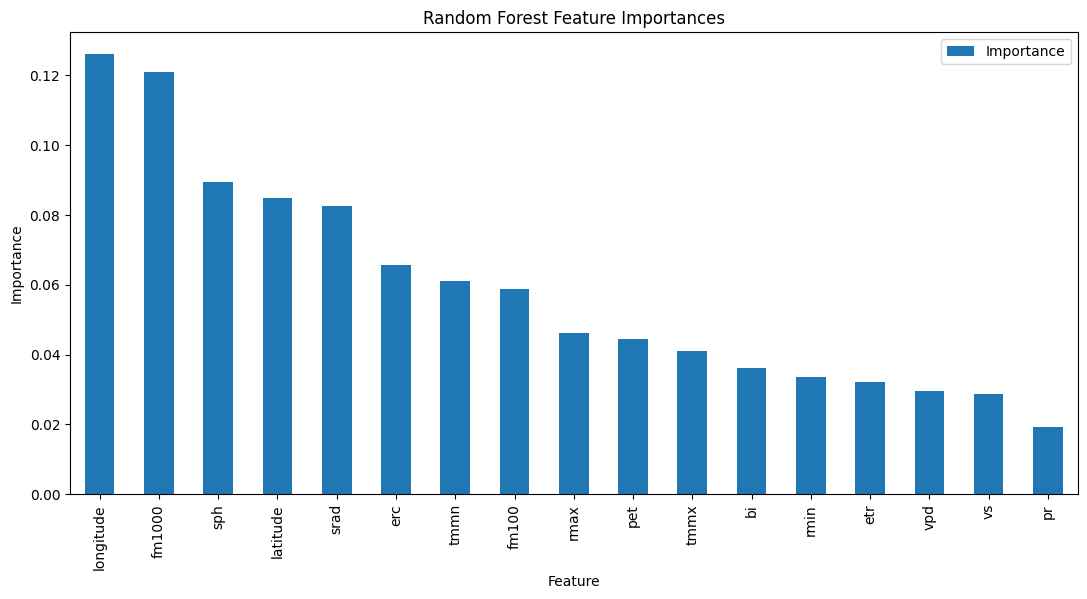

In [18]:
# Get feature importances
rf_feature_importances = wildfires_rf_model.feature_importances_

# Convert to a dataframe
rf_feature_importances_df = pd.DataFrame({
	'Feature': X.columns,
	'Importance': rf_feature_importances
})

# Sort the dataframe from highest to lowest importance
rf_feature_importances_df = rf_feature_importances_df.sort_values('Importance', ascending=False)

print(rf_feature_importances_df)

# Plot the feature importances
rf_feature_importances_df.plot.bar(x='Feature', y='Importance', figsize=(13,6))
plt.title('Random Forest Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')

# Evaluate the data with a 2nd model: Decision Tree

### Define the hyperparameter grid

In [19]:
dt_hyperparam_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 4, 8, 12],
    'max_features': ['sqrt', 'log2', None]
}

### Define the model and grid search

In [20]:
dt_classifier = DecisionTreeClassifier(random_state=42)

dt_grid_search = GridSearchCV(estimator=dt_classifier, param_grid=dt_hyperparam_grid, cv=2)

### Run the grid search and get the best hyperparameters

In [21]:
dt_grid_search.fit(X_train, y_train)

dt_best_hyperparams = dt_grid_search.best_params_

print(dt_best_hyperparams)

{'criterion': 'entropy', 'max_depth': 12, 'max_features': None}


### Define the new model using the best hyperparameters

In [22]:
wildfires_dt_model = DecisionTreeClassifier(
    criterion = 'entropy',
    max_depth = 12,
    max_features = None,
    random_state = 42,
)

wildfires_dt_model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curren

### Generate test set predictions

In [23]:
y_pred_dt = wildfires_dt_model.predict(X_test)

y_pred_dt

array(['No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'Yes', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No', 'No',
       'No', 'No', 'No', 'No', 'No', 'No', 'No'

### Evaluate the Decision Tree results

In [24]:
# Compute the accuracy
dt_acc = accuracy_score(y_test, y_pred_dt)

print('Decision Tree Accuracy:', dt_acc)

Decision Tree Accuracy: 0.961


In [25]:
# Compute precision, recall, and f1-score using classification report
print('Decision Tree Classification Report:\n', classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:
               precision    recall  f1-score   support

          No       0.98      0.98      0.98       955
         Yes       0.57      0.51      0.54        45

    accuracy                           0.96      1000
   macro avg       0.78      0.75      0.76      1000
weighted avg       0.96      0.96      0.96      1000



In [26]:
# Generate confusion matrices
dt_confusion = confusion_matrix(y_test, y_pred_dt)

dt_confusion_df = pd.DataFrame(dt_confusion,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

print("Decision Tree Confusion Matrix:\n")
print(dt_confusion_df)

Decision Tree Confusion Matrix:

            Predicted No  Predicted Yes
Actual No            938             17
Actual Yes            22             23


In [27]:
# Compute the probability of wildfire
dt_prob = wildfires_dt_model.predict_proba(X_test)
dt_fire_prob = dt_prob[:, 1]

# Create a copy of the test feature data with labels
dt_results = X_test.copy()
dt_results['Actual'] = y_test.values

# Add the predicted wildfire probability
dt_results['DT_Prob'] = dt_fire_prob

# Filter only rows where a wildfire actually occurred
dt_wildfire = dt_results[dt_results['Actual'] == 'Yes']
print("Average DT probability (wildfire cases):", dt_wildfire['DT_Prob'].mean())

# Analyze the non-wildfire cases
dt_no_fire = dt_results[dt_results['Actual'] == 'No']
print("Average DT probability (no wildfire):", dt_no_fire['DT_Prob'].mean())

Average DT probability (wildfire cases): 0.5146842754195695
Average DT probability (no wildfire): 0.019999083976226104


### Get and plot feature importances

      Feature  Importance
1   longitude    0.223513
12     fm1000    0.176274
0    latitude    0.161602
5         sph    0.124387
11      fm100    0.111253
6        srad    0.060300
7        tmmn    0.044718
13        erc    0.031237
4        rmin    0.026080
8        tmmx    0.016155
9          vs    0.013781
16        vpd    0.006578
3        rmax    0.004121
2          pr    0.000000
10         bi    0.000000
14        etr    0.000000
15        pet    0.000000


Text(0, 0.5, 'Importance')

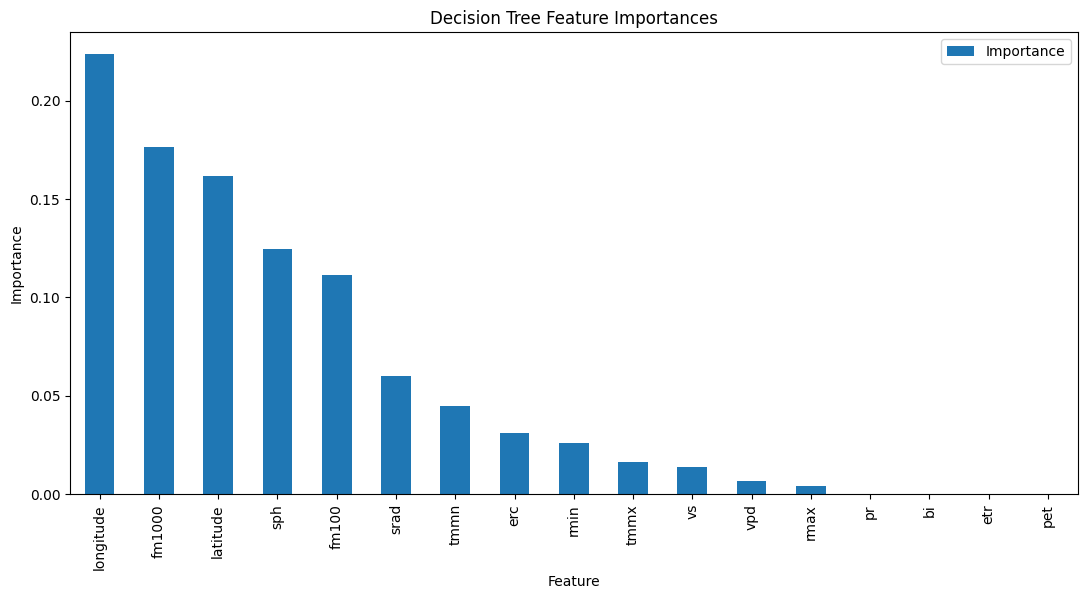

In [28]:
# Get feature importances
dt_feature_importances = wildfires_dt_model.feature_importances_

# Convert to a dataframe
dt_feature_importances_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_feature_importances
})

# Sort the dataframe from highest to lowest importance
dt_feature_importances_df = dt_feature_importances_df.sort_values('Importance', ascending=False)

# Print the dataframe
print(dt_feature_importances_df)

# Plot the feature importances
dt_feature_importances_df.plot.bar(x='Feature', y='Importance', figsize=(13,6))
plt.title('Decision Tree Feature Importances')
plt.xlabel('Feature')
plt.ylabel('Importance')


### Compare model predictions

In [29]:
# Number of matching model predictions
num_agree = (y_pred_rf == y_pred_dt).sum()

# Total number of predictions
total = len(y_pred_rf)

print("Number of predictions where both models agree:", num_agree)
print("Total number of predictions:", total)

Number of predictions where both models agree: 961
Total number of predictions: 1000


In [30]:
print("RF predictions:\n", pd.Series(y_pred_rf).value_counts())
print("\nDT predictions:\n", pd.Series(y_pred_dt).value_counts())
print("\nActual values:\n", y_test.value_counts())

RF predictions:
 No     999
Yes      1
Name: count, dtype: int64

DT predictions:
 No     960
Yes     40
Name: count, dtype: int64

Actual values:
 Wildfire
No     955
Yes     45
Name: count, dtype: int64


### Plot Classification Report to compare RF and DT

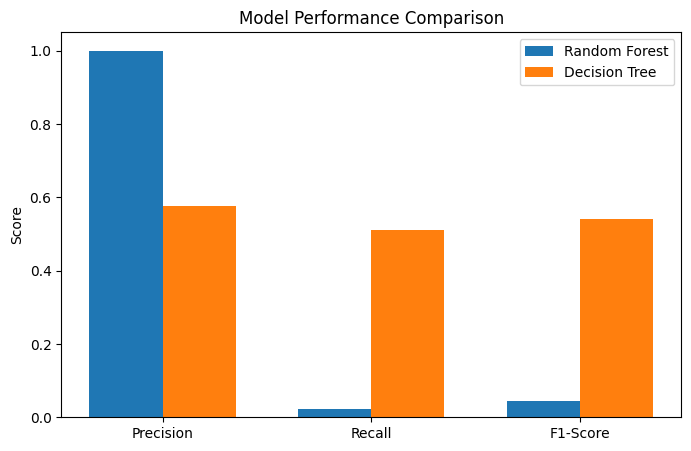

In [31]:
# Convert to dictionary
# Random Forest report
rf_report = classification_report(y_test, y_pred_rf, output_dict=True)

# Decision Tree report
dt_report = classification_report(y_test, y_pred_dt, output_dict=True)

# Extract metrics
rf_precision = rf_report['Yes']['precision']
rf_recall = rf_report['Yes']['recall']
rf_f1 = rf_report['Yes']['f1-score']

dt_precision = dt_report['Yes']['precision']
dt_recall = dt_report['Yes']['recall']
dt_f1 = dt_report['Yes']['f1-score']

# Create comparison plot
metrics = ['Precision', 'Recall', 'F1-Score']

rf_values = [rf_precision, rf_recall, rf_f1]
dt_values = [dt_precision, dt_recall, dt_f1]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - width/2, rf_values, width, label='Random Forest')
plt.bar(x + width/2, dt_values, width, label='Decision Tree')

plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()


### Plot most important feature vs probability

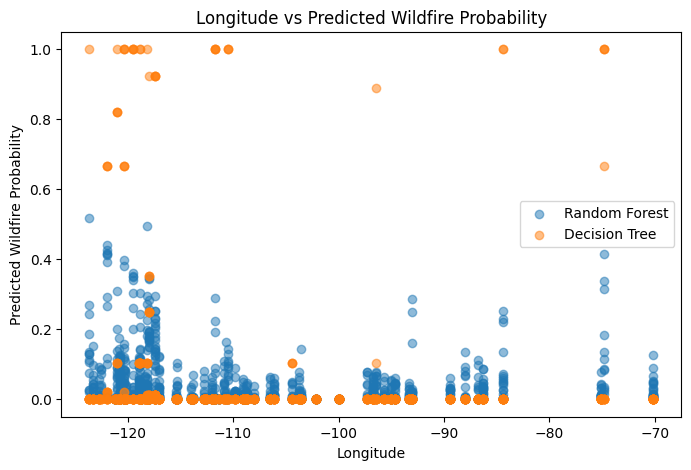

In [32]:
plt.figure(figsize=(8,5))

# Random Forest
plt.scatter(X_test['longitude'], rf_fire_prob, alpha=0.5, label='Random Forest')

# Decision Tree
plt.scatter(X_test['longitude'], dt_fire_prob, alpha=0.5, label='Decision Tree')

plt.xlabel('Longitude')
plt.ylabel('Predicted Wildfire Probability')
plt.title('Longitude vs Predicted Wildfire Probability')
plt.legend()

plt.show()